## 연관 분석 예습 정리

### 목차
1. 연관 분석이란?
2. 주요 개념
3. 활용 사례
4. 연관 분석 알고리즘

---

### 1. 연관 분석이란?

#### 1-1. 연관 분석의 정의

- **연관 분석**  
: 항목 간 일정한 연관 규칙을 발견하는 분석
    - 다양한 분야에 활용 가능
    - **비지도 학습**에 해당
    - 주요 알고리즘: `Apriori`, `FP-Growth`

#### 1-2. 연관 규칙 분석

- **연관 규칙의 형태**  
: `if-then` 형식, `A → B`로 표현
    - **조건절(Antecedent):** `만일 ~라면`
    - **결과절(Consequent):** 그 뒷부분
    - **아이템 집합(Item set):** 조건절 또는 결과절을 구성하는 아이템들의 집합 (상호 배반)

- **주의점: 상관관계 ≠ 인과관계**
    - 실험이 아닌 관찰 데이터라 원인 통제 불가
    - 방향성은 그냥 수학적 비율일 뿐

---

### 2. 주요 개념

#### 2-1. 적절한 연관규칙의 조건
- **지지도 (Support)**  
: 전체 거래 중 품목 A와 품목 B가 동시에 포함된 거래의 비율
    - $지지도 = P(A ∩ B)$
    - 지지도 낮으면
        - 우연히 신뢰도 높을 수 있음
        - 현실 적용 어려움

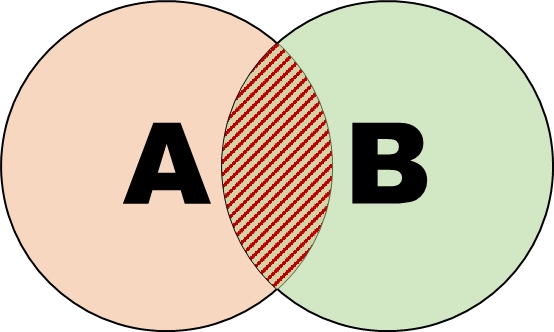

- **신뢰도 (Confidence)**  
: 품목 A를 포함하는 거래 중 품목 B도 포함하는 거래의 비율
    - $신뢰도 = P(A ∩ B) / P(A)$
    - 신뢰도 낮으면
        - 의미 없는 연관 규칙
        - 추천 실패로 이어짐

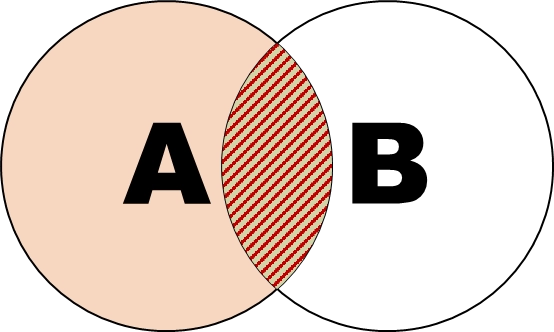

#### 2-2. 연관 분석의 평가 측도

- **향상도 (Lift)**  
: 두 품목이 우연히 함께 등장할 확률 대비, **실제 함께 등장할 확률**의 비율
    - $향상도 = P(A ∩ B) / (P(A) * P(B)) = 신뢰도 / P(B)$

    - 사건 A와 B 독립
        - $향상도 = \dfrac{P(A∩B)}{P(A)⋅P(B)} = \dfrac{P(A)⋅P(B)}{P(A)⋅P(B)}=1$
        - 향상도 1
    - 사건 A와 B 독립 x
        - 향상도 1보다 크거나 작음

    - **향상도 > 1**: 양의 상관관계 (A를 사면 B도 살 확률이 우연보다 높음)
    - **향상도 = 1**: 독립
    - **향상도 < 1**: 음의 상관관계 (A를 사면 오히려 B를 안 삼)

- **평가 기준:** 지지도, 신뢰도, 향상도 **세 가지 지표가 모두 높을 때** 유의미

---

### 3. 활용 사례

#### 3-1. 월마트 Case

- **상황:** 허리케인 경보 시, '딸기맛 팝타르트'의 판매량 7배 급증
- **연관 분석:**
  - **지지도:** '재난 대비 용품 + 팝타르트' 조합 상승
  - **신뢰도:** 재난 물품 살 때 팝타르트 함께 사는 비율 높음
  - **향상도 (Lift > 1):** 강한 양의 상관관계 
- **결론:** 물류 투입 실행 (성공적 의사결정)

---

### 4. 연관 분석 알고리즘

#### 4-1. Apriori 알고리즘

- **개념**   
: 어떤 조합이 자주 발생하지 않으면, 후속 조합들까지 배제하는 알고리즘

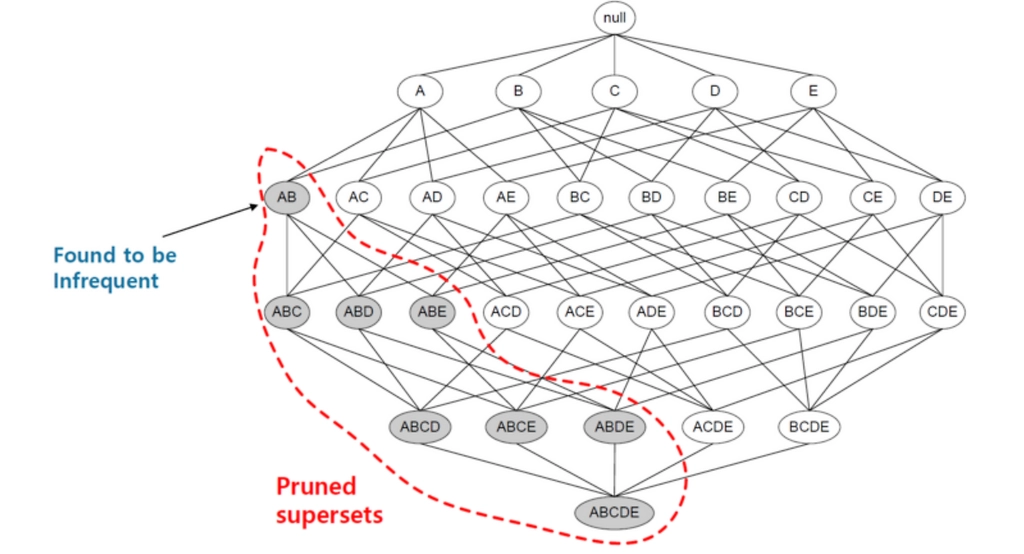

- **프로세스** 
    1) 단일 항목 집합 생성
        - 모든 항목 지지도 계산
        - 최소 지지도 넘으면 다음 단계
    2) 2개 항목 집합 생성
        - 2개 항목의 조합 지지도 계산
        - 최소 지지도 안 넘으면 제거
    3) 더 큰 항목 집합 생성
        - 3개 이상 항목의 조합 지지도 계산
        - 최소 지지도 안 넘으면 제거
        - 조합이 더 이상 생성되지 않을 때까지 반복
    4) 최종 빈발 항목 집합 선정
        - **빈발 항목 집합:** 일정한 최소 지지도를 넘는 항목들의 조합
        - 연관 규칙 생성

- **장점** 
    - 모든 조합 시도할 필요 없음
    - 드는 시간과 연산량 감소
    - 수많은 상품 연관 구매 패턴 발견

- **단점** 
    - 데이터 커질수록 속도 느려짐

#### 4-2. FP-Growth 알고리즘

- **개념**  
: **FP-Tree**라는 구조를 활용한 알고리즘

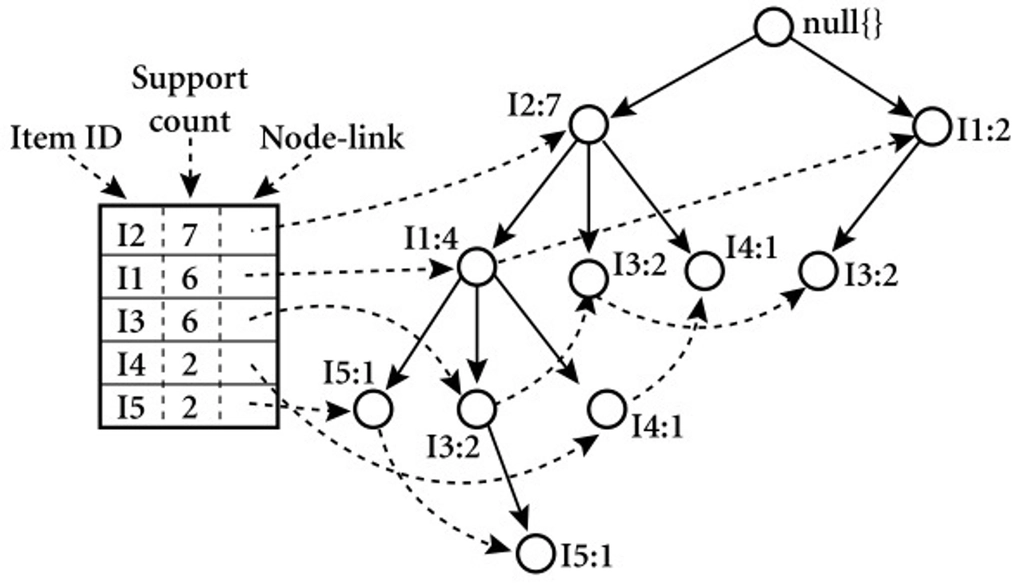

- **프로세스**   
    1) 데이터셋 확인
    2) 빈도순 재정렬
        - 가장 자주 구매된 항목이 먼저 오도록 재정렬 (f-list)
    3) FP-트리 생성
        - 각 거래 노드로 표현
        - 동일 항목 기존 노드에 연결
        - 새로운 항목 새로운 노드에 추가
    4) 빈발 항목 집합 추출
        - 특정 항목 기준으로 만든 부분 트리에서 추출
    5) 연관 규칙 도출
        - 지지도, 신뢰도, 향상도 계산

- **장점** 
    - Apriori보다 빠름
    - 후보 itemset 생성할 필요 x

- **단점** 
    - 대용량 데이터에서 메모리 사용이 비효율적
    - 트리 설계, 지지도 계산 준비가 복잡함

---

## 경영 기초 예습 정리

### 목차
1. 문제 정의
2. 문제 구조화
3. 지표
4. 지표 분석 방법
5. 효과 검증

---

### 1. 문제 정의

#### 1-1. 현상과 문제 구분

- **현상**   
: 관찰된 단순한 사실

- **문제**  
: 현재 상태와 바라는 상태의 격차이며, 해결해야 할 질문

#### 1-2. Problem Statement

1. **배경 (Situation):** 지금까지 무슨 일이 있었나?
2. **문제 (Complication):** 무엇이 달라졌나?
3. **질문 (Question):** 무엇에 답해야 하나?
4. **의사결정:** 이 답으로 누가 무엇을 결정하나?
5. **판단 기준:** 어떤 숫자가 나오면 어떤 선택을 할 것인가? (기준이 없으면 행동으로 이어지지 않음)

---

### 2. 문제 구조화

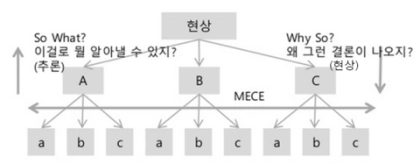

#### 2-1. MECE 

- **상호 배타적 (중복 방지):** 겹치는 부분이 없어야 함
- **전체 포괄적 (누락 방지):** 빠지는 부분이 없어야 함
- **좋은 MECE의 조건:** 논리적 일관성, 문제 해결에 도움 되는 통찰력, 서로 다른 대응으로 이어지는 행동 가능성

#### 2-2. 로직 트리

1. 문제 정의
2. 이슈 트리 작성
3. 가설 수립 
4. 분석 설계 
5. 검증 → 결론

#### 2-3. 분해 등식

- 지표를 **곱셈 등식**으로 쪼개는 방식
- 예: `매출 = 고객 수 × 구매 빈도 × 객단가`

---

### 3. 지표 

- **지표**  
: 측정하고 싶은 것을 숫자로 표현한 것

#### 3-1. 지표 유형

- **효율성:** 산출 ÷ 투입 (예: 노동 생산성)
- **효과성:** 달성 ÷ 목표 (예: 목표 달성률)
- **수익성:** 이익 ÷ 자원 (예: ROE)
- **성장성:** 증가분 ÷ 기존 규모 (예: 매출 성장률)
- **안정성:** 보유 ÷ 부채 (예: 부채 비율)

#### 3-2. 좋은 지표를 고르는 세 가지 축

1. **선행 vs 후행**
    - **선행 지표:** 원인
    - **후행 지표:** 결과

2. **투입 (Input) vs 산출 (Output)**
    - **Output:** 결과
    - **Input:** 통제할 수 있는 행동 (목표)

3. **가드레일 지표 (Guardrail Metric)**   
: 지표 방어선

#### 3-3. 대리 지표 (Proxy Metric)

- 직접 측정 불가능한 개념을 관찰 가능한 수치로 대체한 지표
- 예: 만족도 → 가입 후 1주일 이내 진입률

#### 3-4. L1 / L2

- **L1 (전략):** 성과 지표 (예: 총 거래액)
- **L2 (전술):** L1을 구성하는 세부 지표 (예: 방문자 수, 구매 전환율)
- L1 = L2의 조합 설계가 핵심

#### 3-5. KPI (Key Performance Indicator)

- 현재 위치를 알려주는 '나침반'
- 모두가 이해할 수 있는 객관적 기준

#### 3-6. KSF (Key Success Factor)

- 목표 달성의 성패를 가르는 소수의 결정적 요인 
- **조건:** 소수성, 결정성, 통제 가능성, 상황 의존성

---

### 4. 지표 분석 방법

#### 4-1. 변동 분해

- 곱셈 분해 (요소별 확인)
- 전체 평균이 움직였을 때 원인
    - **단가 효과:** 각 항목의 값 자체가 변함 (가격, 원가 구조 확인)
    - **믹스 효과:** 항목별 판매 비중이 변함 (판매 구성, 채널 전략 확인)

#### 4-2. RFM 분석

- 고객을 세 가지 축으로 나누어 등급화
    - **R (Recency, 최근성):** 마지막 구매가 얼마나 최근인가? 
    - **F (Frequency, 빈도):** 얼마나 자주 구매했는가?
    - **M (Monetary, 금액):** 얼마나 많이 썼는가?
- 결과가 바로 실행 계획이 됨

---

### 5. 효과 검증 (A/B 테스트)

- **랜덤 배정:** 대조군과 실험군을 무작위로 나눌 것
- **사전 지표 합의:** 무엇을 성공으로 볼지 실험 전에 정할 것
- **충분한 표본:** 필요한 표본 크기를 미리 계산할 것
- **피킹(Peeking) 금지:** 유리한 순간에 중단하지 말 것
- **가드레일 확인:** 목표 지표 상승 외 다른 지표도 확인할 것

- A/B 테스트 불가능할 때
    - 전후 비교 + 유사 특성의 대조군 활용
    - 일부 단계적 적용 후 나머지 비교
    - 계절성 제거를 위한 전년 동기 시계열 비교

- 제안 시 반드시 숫자로 된 기대효과 붙임
- `기대효과 = 영향받는 대상 규모 × 개선 폭 (가정) × 단위당 가치`